# 1. Importing Libraries
Importing necessary libraries for computer vision (OpenCV), data manipulation (Pandas, NumPy), visualization (Matplotlib), and machine learning (Scikit-Learn).

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Loading the Dataset
Defining the file paths and dynamically loading all images for the 5 rice classes (Arborio, Basmati, Ipsala, Jasmine, and Karacadag).

In [ ]:
dataset_path = "/content/drive/MyDrive/Rice_Image_Dataset"

# Define all 5 classes
categories = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

# Dictionary to store file paths for each class
image_files = {category: [] for category in categories}

# Loop through each category and load ALL images
for category in categories:
    folder_path = os.path.join(dataset_path, category)

    # List all files in the directory
    for file_name in os.listdir(folder_path):
        image_files[category].append(os.path.join(folder_path, file_name))

    print(f"{category} images loaded: {len(image_files[category])}")

Arborio images loaded: 15000
Basmati images loaded: 15004
Ipsala images loaded: 15016
Jasmine images loaded: 15000
Karacadag images loaded: 15000


# 3. Exploratory Data Analysis (EDA)
Visualizing a random sample image from each of the 5 classes alongside its grayscale pixel intensity histogram to observe differences in their distributions.

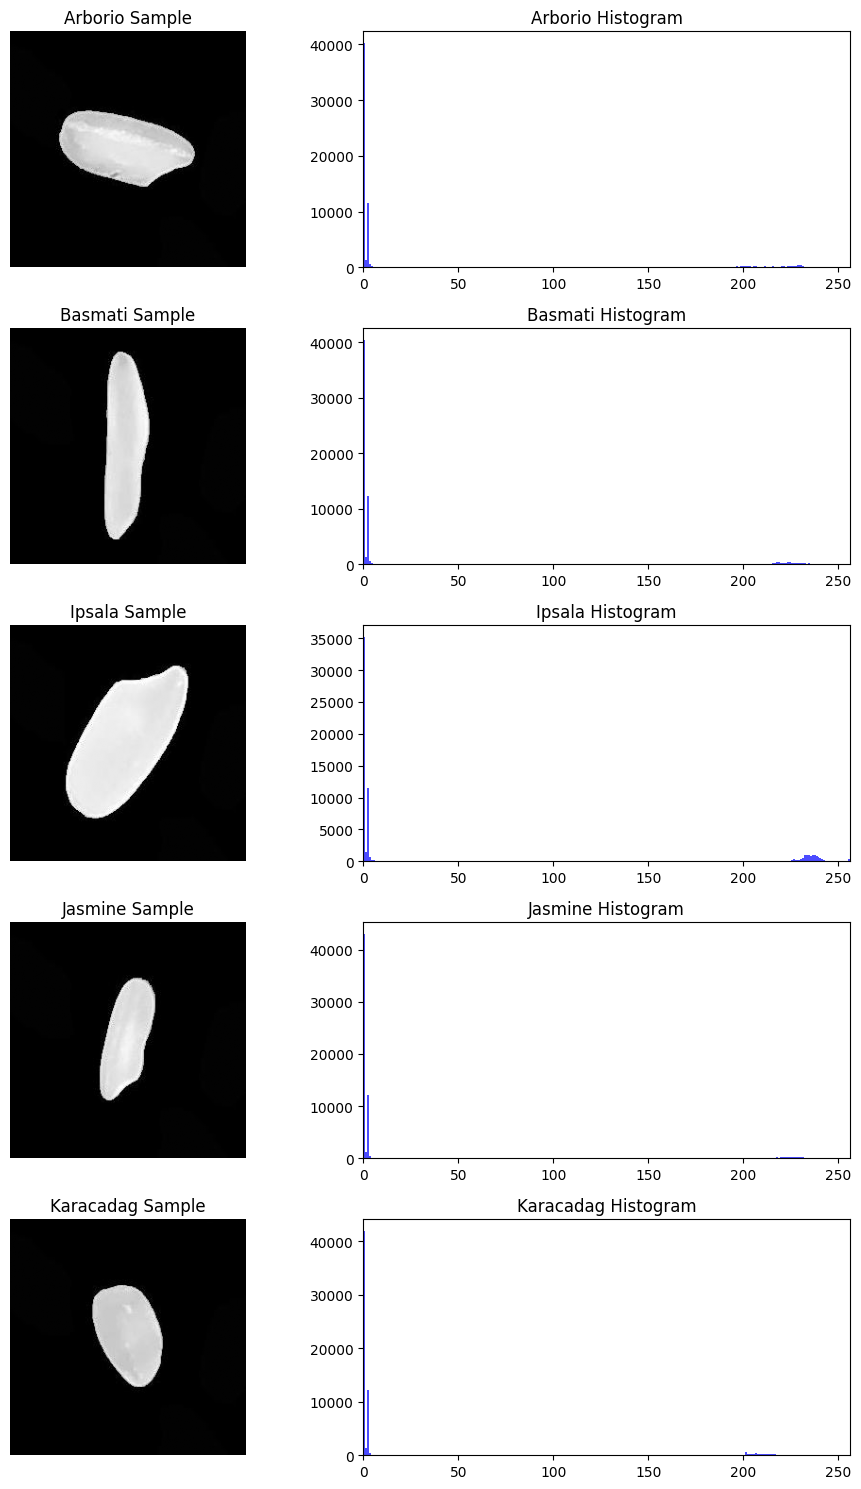

In [ ]:
# Create a plot with 5 rows (one for each class) and 2 columns (Image, Histogram)
fig, axes = plt.subplots(5, 2, figsize=(10, 15))

for i, category in enumerate(categories):
    # Select 1 random image from the current class
    sample_img_path = random.choice(image_files[category])

    # Read image in grayscale
    img_gray = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)

    # Plot Image
    axes[i, 0].imshow(img_gray, cmap='gray')
    axes[i, 0].set_title(f"{category} Sample")
    axes[i, 0].axis('off')

    # Plot Histogram
    axes[i, 1].hist(img_gray.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
    axes[i, 1].set_title(f"{category} Histogram")
    axes[i, 1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

# 4. Defining Preprocessing & Feature Extraction Functions
Creating reusable functions to process the images.
* **`preprocess_image`**: Applies a Gaussian blur and binary thresholding.
* **`extract_features`**: Finds contours and calculates geometric features (Area, Perimeter, Eccentricity, Compactness).

In [ ]:
def preprocess_image(image_path):
    img = cv2.imread(image_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    _, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

    return thresh

In [ ]:
def extract_features(binary_img):

    contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)

    perimeter = cv2.arcLength(cnt, True)

    # Eccentricity
    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        (center, axes, angle) = ellipse

        major_axis = max(axes)
        minor_axis = min(axes)

        eccentricity = np.sqrt(1 - (minor_axis/major_axis)**2)
    else:
        eccentricity = 0

    # Compactness
    if area != 0:
        compactness = (perimeter**2) / (4 * np.pi * area)
    else:
        compactness = 0

    return [area, perimeter, eccentricity, compactness]

# 5. Visualizing the Preprocessing Pipeline
Demonstrating the step-by-step transformation (Grayscale -> Blur -> Threshold -> Contours) on a single sample image to verify the logic.

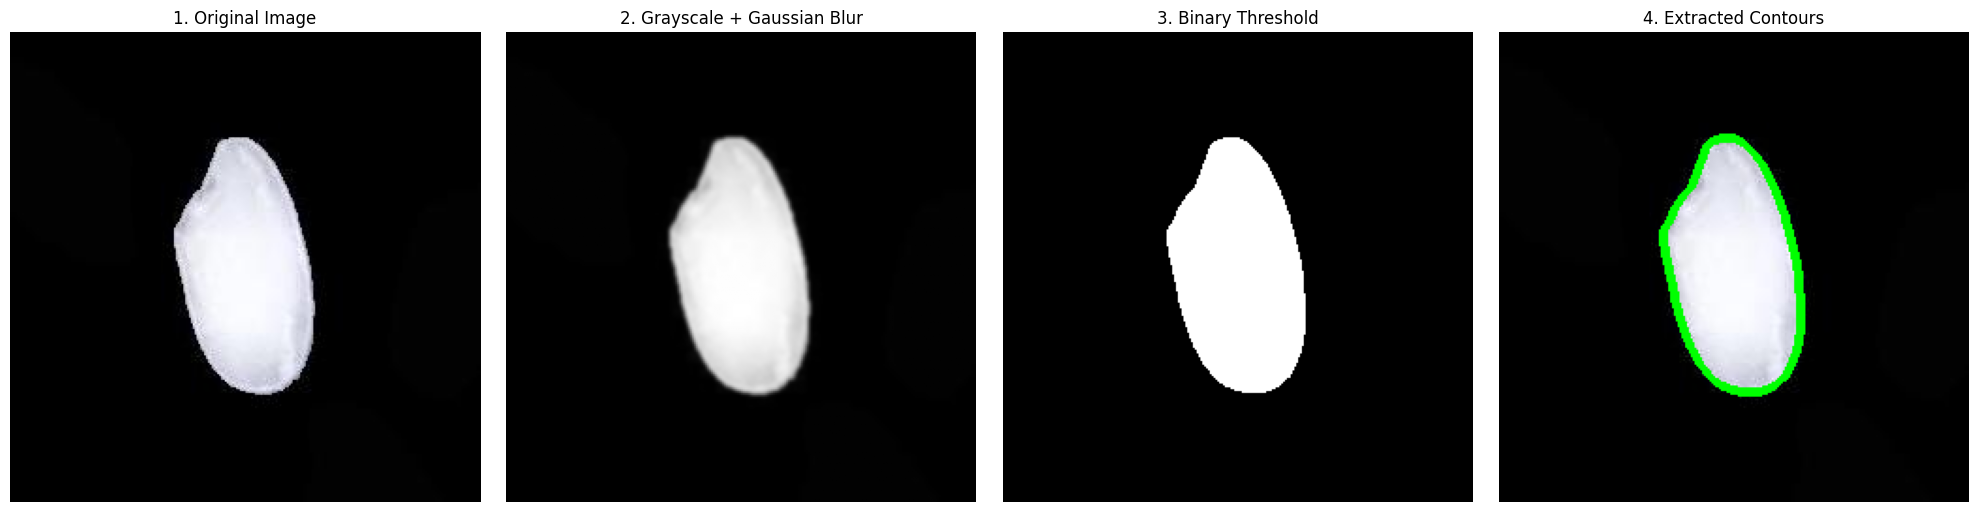

In [ ]:
# Grab one sample image from the first category to demonstrate the pipeline
sample_img_path = image_files[categories[0]][0]

# 1. Read and convert for plotting
img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Original
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Apply preprocessing steps
blur = cv2.GaussianBlur(gray, (5, 5), 0)
_, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

# 3. Find contours to show feature extraction
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_img = img_rgb.copy()
cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 3)

# Plot the steps side-by-side
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("1. Original Image")
axes[0].axis('off')

axes[1].imshow(blur, cmap='gray')
axes[1].set_title("2. Grayscale + Gaussian Blur")
axes[1].axis('off')

axes[2].imshow(thresh, cmap='gray')
axes[2].set_title("3. Binary Threshold")
axes[2].axis('off')

axes[3].imshow(contour_img)
axes[3].set_title("4. Extracted Contours")
axes[3].axis('off')

plt.tight_layout()
plt.show()

# 6. Building the Feature Dataset
Looping through all images to extract their geometric features and storing them in a structured Pandas DataFrame along with their corresponding assigned integer labels (0 to 4).

In [ ]:
data = []

# Loop through categories and automatically assign an integer label
for label, category in enumerate(categories):
    print(f"Extracting features for {category} (Label: {label})...")

    for file in image_files[category]:
        processed = preprocess_image(file)
        features = extract_features(processed)

        if features:
            data.append(features + [label])

columns = ["Area", "Perimeter", "Eccentricity", "Compactness", "Label"]
df = pd.DataFrame(data, columns=columns)

print("\nSample Data:")
print(df.sample(10))

Extracting features for Arborio (Label: 0)...
Extracting features for Basmati (Label: 1)...
Extracting features for Ipsala (Label: 2)...
Extracting features for Jasmine (Label: 3)...
Extracting features for Karacadag (Label: 4)...

Sample Data:
          Area   Perimeter  Eccentricity  Compactness  Label
6274    8105.0  372.333041      0.854102     1.361132      0
1005    8105.5  370.492421      0.835657     1.347625      0
70620   5594.5  296.007140      0.781799     1.246331      4
48981   4994.5  330.149276      0.941383     1.736676      3
56430   7817.0  438.156415      0.967248     1.954377      3
53143   4936.0  319.019333      0.945067     1.640775      3
37817  12835.0  486.132032      0.888156     1.465220      2
33036  16000.0  549.955404      0.886790     1.504268      2
67292   6535.0  318.190907      0.798046     1.232878      4
40343  14353.5  520.457931      0.897310     1.501771      2


# 7. Data Splitting
Separating the independent variables (Features) from the dependent variable (Label) and splitting the data into training (80%) and testing (20%) sets.

In [ ]:
X = df[["Area", "Perimeter", "Eccentricity", "Compactness"]]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. Model Training
Initializing and training a K-Nearest Neighbors (KNN) classifier using `k=3` on the training dataset.

In [ ]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

# 9. Model Evaluation
Evaluating the model's performance on the unseen test data using Accuracy, a Confusion Matrix, and a Classification Report to understand how well it differentiates all 5 classes.

In [ ]:
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9698747000799787

Confusion Matrix:
 [[2848    0    1   12  136]
 [   2 2924    0   63    0]
 [  11    0 3000   10    0]
 [  17   78    3 2937    1]
 [ 118    0    0    0 2843]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      2997
           1       0.97      0.98      0.98      2989
           2       1.00      0.99      1.00      3021
           3       0.97      0.97      0.97      3036
           4       0.95      0.96      0.96      2961

    accuracy                           0.97     15004
   macro avg       0.97      0.97      0.97     15004
weighted avg       0.97      0.97      0.97     15004



# 10. Building the Prediction Pipeline
Creating a function that takes a raw image path, runs it through the preprocessing and feature extraction steps, and outputs the model's prediction.

In [ ]:
def predict_image(image_path):

    processed = preprocess_image(image_path)
    features = extract_features(processed)

    if features:
        features_df = pd.DataFrame([features], columns=["Area", "Perimeter", "Eccentricity", "Compactness"])
        prediction = model.predict(features_df)
        return prediction[0]
    else:
        return None

In [ ]:
# 1. Pick a sample image from any of your 5 categories
# (You can change 'Jasmine' to 'Arborio', 'Basmati', etc., to test others)
test_img = image_files['Jasmine'][0]

# 2. Get the numeric prediction (0 through 4)
result_idx = predict_image(test_img)

# 3. Map the number back to the grain name using your categories list
if result_idx is not None:
    predicted_class = categories[result_idx]
    print(f"\nPredicted: {predicted_class}")
else:
    print("\nUnable to detect rice grain")


Predicted: Jasmine


# 11. Interactive Prediction (Upload an Image)
An interactive cell that allows you to upload an image from your local machine and get a live prediction from the trained model across all 5 rice classes.

Saving Jasmine (3165).jpg to Jasmine (3165).jpg

Predicted: Jasmine


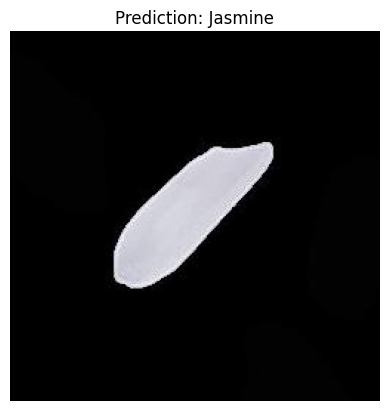

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# 1. Upload the file from your local machine
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Predict using your existing function
    result_idx = predict_image(filename)

    # 3. Display the result dynamically using the categories list
    if result_idx is not None:
        prediction = categories[result_idx]
    else:
        prediction = "Unable to detect rice grain"

    print(f"\nPredicted: {prediction}")

    # 4. Show the image you uploaded
    img = cv2.imread(filename)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {prediction}")
    plt.axis('off')
    plt.show()

# 12. Automated Random Prediction Test
Randomly selecting a batch of images from the entire dataset to test the prediction pipeline programmatically. This visualizes the true labels versus the predicted labels, coloring the text green for correct matches and red for errors.

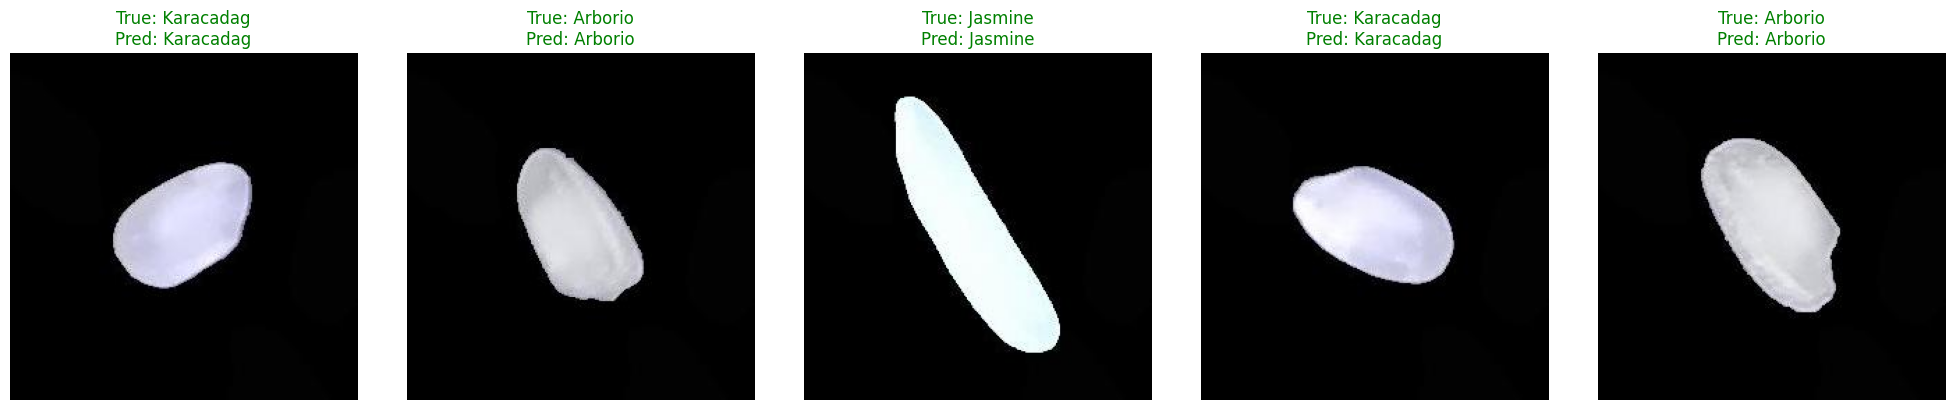

In [ ]:
import random
import matplotlib.pyplot as plt
import cv2

num_samples = 5 # Change this number to test more images at once

# Combine all image paths and their true labels into a single list
all_test_images = []
for category in categories:
    for img_path in image_files[category]:
        all_test_images.append((img_path, category))

# Randomly select a batch of images
sample_batch = random.sample(all_test_images, num_samples)

# Set up a plot to display the results side-by-side
fig, axes = plt.subplots(1, num_samples, figsize=(20, 4))
if num_samples == 1:
    axes = [axes]

for i, (img_path, true_label) in enumerate(sample_batch):
    result_idx = predict_image(img_path)

    if result_idx is not None:
        predicted_label = categories[result_idx]
    else:
        predicted_label = "Unknown"

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)

    title_color = "green" if predicted_label == true_label else "red"
    axes[i].set_title(f"True: {true_label}\nPred: {predicted_label}", color=title_color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()